###  Precision (Precyzja), Recall (Czułość) i Ich Zastosowanie

Precision (Precyzja) i Recall (Czułość) to kluczowe metryki do oceny działania **binarnego klasyfikatora**, szczególnie gdy mamy do czynienia z **danymi niezbalansowanymi** (gdzie jedna klasa jest znacznie liczniejsza niż druga). Są one używane do pomiaru tego, jak dobrze model radzi sobie z identyfikacją klasy pozytywnej.

---

### 1. Precision (Precyzja)

Precyzja mówi o **jakości** predykcji klasy pozytywnej (klasy 1).

* **Pytanie:** Spośród **wszystkich próbek, które model sklasyfikował jako pozytywne**, jaki odsetek był faktycznie pozytywny?

$$\text{Precision} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$
* **Interpretacja:** Wysoka precyzja oznacza, że gdy model mówi, że coś jest pozytywne, jest **duże prawdopodobieństwo, że ma rację** (niska liczba fałszywych alarmów/FP).

---

### 2. Recall (Czułość,  True Positive Rate)

Czułość mówi o **kompletności** identyfikacji klasy pozytywnej (klasy 1).

* **Pytanie:** Spośród **wszystkich faktycznie pozytywnych próbek** (klasa 1), jaki odsetek został poprawnie zidentyfikowany przez model?
    $$\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$
* **Interpretacja:** Wysoka czułość oznacza, że model jest **skuteczny w odnajdywaniu wszystkich pozytywnych przypadków** (niska liczba pominiętych przypadków/FN).

---

### Przykład Zastosowania

Wyobraźmy sobie klasyfikator, którego zadaniem jest wykrywanie **rzadkiej choroby (Klasa 1)** w populacji. Mamy 100 osób, z czego tylko 10 jest faktycznie chorych.

| Wynik | Faktycznie Pozytywne (Chorzy) | Faktycznie Negatywne (Zdrowi) | Suma |
| :---: | :---: | :---: | :---: |
| **Przewidziane Pozytywne** | **TP = 8** | **FP = 4** | 12 |
| **Przewidziane Negatywne** | **FN = 2** | **TN = 86** | 88 |
| **Suma** | 10 | 90 | 100 |

#### Obliczenia Metryk




In [2]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Faktyczne etykiety (10 chorych, 90 zdrowych) - Łącznie 100 próbek
y_true = np.array([1] * 10 + [0] * 90)

# Corrected values from the example confusion matrix in the markdown cell
TP = 5  # True Positives
FN = 5  # False Negatives
FP = 5  # False Positives
TN = 95 # True Negatives

# --- 2. Konstrukcja Wetora y_kpred ---

# Predictions for the 10 actual positive samples (first 10 elements of y_true)
# TP (1s) followed by FN (0s)
pred_for_positives = np.concatenate([np.ones(TP), np.zeros(10 - TP)]).astype(int)

# Predictions for the 90 actual negative samples (last 90 elements of y_true)
# FP (1s) followed by TN (0s)
pred_for_negatives = np.concatenate([np.ones(FP), np.zeros(90 - FP)]).astype(int)

y_pred = np.concatenate([pred_for_positives, pred_for_negatives])


# Weryfikacja: Wektor y_pred powinien mieć łączną długość 100
dlugosc_wektora = len(y_pred)
print(f"TP: {TP}, FN: {FN}, FP: {FP}, TN: {TN}")
print(f"Całkowita liczba próbek: {dlugosc_wektora}")
print(f"Fragment wektora y_pred: {y_pred[:15]}")


# 1. Macierz Konfuzji (dla weryfikacji TP, FP, FN, TN)
# Zwraca: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()



# 2. Obliczanie Precision i Recall
precyzja = precision_score(y_true, y_pred, zero_division=0)
czulosc = recall_score(y_true, y_pred, zero_division=0)

print("### Wyniki Oceny Klasyfikatora")
print(f"Liczba faktycznie chorych (Klasa 1): {tp + fn}")
print(f"Macierz Konfuzji (TP={tp}, FP={fp}, FN={fn}, TN={tn})")
print("-" * 30)

# Precision
print("1. Precision (Precyzja):")
#
print(f"Precyzja = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {tp / (tp + fp) if (tp + fp) > 0 else 0:.4f}")
print(f"    -> {precyzja:.4f}")
# Recall
print("\n2. Recall (Czułość):")
#
print(f"Czułość = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {tp / (tp + fn) if (tp + fn) > 0 else 0:.4f}")
print(f"    -> {czulosc:.4f}")

TP: 5, FN: 5, FP: 5, TN: 95
Całkowita liczba próbek: 100
Fragment wektora y_pred: [1 1 1 1 1 0 0 0 0 0 1 1 1 1 1]
### Wyniki Oceny Klasyfikatora
Liczba faktycznie chorych (Klasa 1): 10
Macierz Konfuzji (TP=5, FP=5, FN=5, TN=85)
------------------------------
1. Precision (Precyzja):
Precyzja = TP / (TP + FP) = 5 / (5 + 5) = 0.5000
    -> 0.5000

2. Recall (Czułość):
Czułość = TP / (TP + FN) = 5 / (5 + 5) = 0.5000
    -> 0.5000


In [ ]:
TP

0

### Pytania Kontrolne


---

#### 1. Przypadki Skrajne Precyzji

* **Pytanie:** W jakiej sytuacji (przy założeniu, że model przewidział co najmniej jedną klasę pozytywną) osiągamy **Precision (Precyzję) równą 1.0**?

---

#### 2. Przypadki Skrajne Czułości

* **Pytanie:** W jakiej sytuacji osiągamy **Recall (Czułość) równą 0.0**?

---

#### 3. Wzajemny Kompromis (Trade-off)

* **Pytanie:** Jaki jest typowy **związek** między Precision a Recall? Czy model może łatwo osiągnąć jednocześnie bardzo wysokie Precision ($>0.9$) i bardzo wysokie Recall ($>0.9$), szczególnie w przypadku rzadkich klas?
* **Odpowiedź:** Zazwyczaj istnieje **kompromis (trade-off)**. Poprawienie Czułości (Recall) często prowadzi do obniżenia Precyzji i na odwrót. Jest to spowodowane tym, że próba znalezienia wszystkich (wysoki Recall) wymusza obniżenie pewności, a przez to zwiększa się ryzyko Fałszywie Pozytywnych (wzrost FP, spadek Precision).

---

#### 4. Wpływ Błędów na Metryki

* **Pytanie:** W której metryce: **Precision** czy **Recall**, dominujący wpływ na wynik mają **Fałszywie Pozytywne (FP)**, a w której **Fałszywie Negatywne (FN)**?

---

#### 5. Scenariusze Zastosowania

* **Pytanie:** W dwóch różnych scenariuszach: **a)** system ostrzegania przed tsunami (gdzie przeoczenie jest katastrofą) oraz **b)** algorytm rekomendujący produkty w sklepie internetowym (gdzie fałszywe rekomendacje denerwują klienta):
    * W scenariuszu **a** (tsunami) dążymy do maksymalizacji **Precision** czy **Recall**?
    * W scenariuszu **b** (rekomendacje) dążymy do maksymalizacji **Precision** czy **Recall**?

In [3]:
y_true,y_pred

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

###  Krzywa ROC (Receiver Operating Characteristic) i jej zastosowanie w k-NN

Krzywa **ROC** (Receiver Operating Characteristic) to graficzna metoda oceny działania **binarnego klasyfikatora** przy różnych progach dyskryminacji. Jest to fundamentalne narzędzie w dziedzinie uczenia maszynowego, szczególnie przydatne do wizualizacji i porównywania modeli.

---

### Jak interpretujemy krzywą ROC?

Krzywą ROC wykreślamy na płaszczyźnie, gdzie:

* **Oś Y:** **Czułość (True Positive Rate, TPR)** – Jest to odsetek poprawnie zidentyfikowanych pozytywnych próbek (Prawdziwie Pozytywnych) spośród wszystkich faktycznych próbek pozytywnych.
$$TPR = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
* **Oś X:** ** (False Positive Rate, FPR)** – Jest to odsetek niepoprawnie zidentyfikowanych pozytywnych próbek (Fałszywie Pozytywnych) spośród wszystkich faktycznych próbek negatywnych.
$$FPR = \frac{\text{FP}}{\text{FP} + \text{TN}}$$

Idealny klasyfikator, który osiąga 100% TPR i 0% FPR, znajdowałby się w lewym górnym rogu wykresu (punkt **(0, 1)**). Klasyfikator losowy biegnie wzdłuż przekątnej linii (od (0, 0) do (1, 1)).

---

### **Pole pod krzywą (AUC - Area Under the Curve)**

**AUC** to pojedyncza wartość liczbowa (zwykle między 0.5 a 1.0), która podsumowuje wydajność klasyfikatora dla wszystkich możliwych progów.

* **Im wyższe AUC (bliżej 1.0)**, tym lepsza zdolność modelu do rozdzielania klas.
* **AUC = 0.5** oznacza, że model działa nie lepiej niż losowe zgadywanie.

---

### Zastosowanie Krzywej ROC dla klasyfikatora k-NN

Klasyfikator **k-Najbliższych Sąsiadów (k-NN)** jest z natury modelem, który zwraca etykietę klasy (0 lub 1). Aby narysować krzywą ROC, **potrzebujemy prawdopodobieństwa (lub oceny pewności) przynależności do klasy, a nie tylko twardej etykiety**.

1.  **Obliczanie Prawdopodobieństwa w k-NN:**
    * W przypadku k-NN, zamiast zwracać tylko większość głosów (`k` sąsiadów), model zwraca **proporcję** sąsiadów należących do klasy pozytywnej.
    * *Przykład:* Jeśli $k=5$, a 4 sąsiadów to klasa 1, a 1 to klasa 0, prawdopodobieństwo dla klasy 1 wynosi **0.8**. Ta wartość 0.8 staje się **oceną pewności** dla danej próbki.
2.  **Generowanie Punktów ROC:**
    * **Stosujemy różne progi** do tych prawdopodobieństw (np. 0.1, 0.2, 0.3, ... 1.0).
    * Dla każdego progu klasyfikujemy próbki i obliczamy odpowiadające pary **(FPR, TPR)**.
    * *Przykład:* Jeśli próg wynosi 0.6, próbki z prawdopodobieństwem $\ge 0.6$ są klasyfikowane jako pozytywne (1), a pozostałe jako negatywne (0).
3.  **Kreślenie Krzywej:**
    * Zgromadzone punkty (FPR, TPR) dla różnych progów **kreślimy** na wykresie, tworząc krzywą ROC, a następnie **obliczamy AUC**.

W ten sposób krzywa ROC pozwala nam ocenić, jak dobrze klasyfikator ( w tym przypadku k-NN) równoważy wykrywanie poprawnych pozytywnych próbek (TPR) z unikaniem fałszywych alarmów (FPR) w zadaniu klasyfikacji binarnej.

---



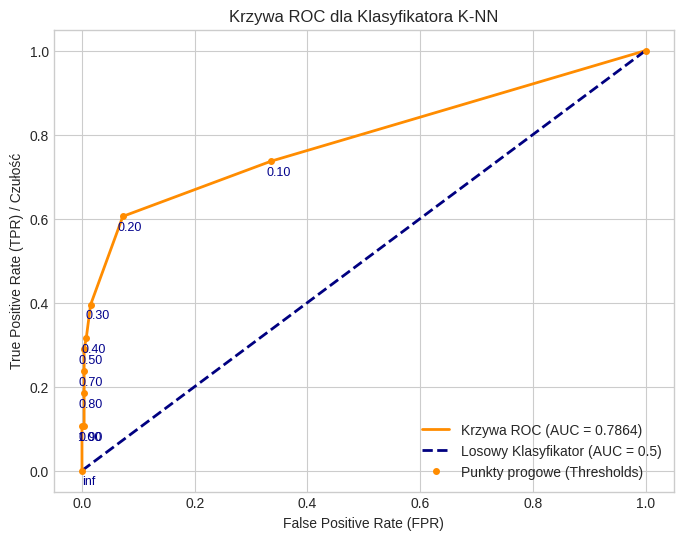


Wynik AUC dla K-NN (K=5): 0.7864
Model jest lepszy niż losowe zgadywanie.


In [15]:
# Import niezbędnych bibliotek
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Ustawienia wykresu dla lepszej widoczności w Colab
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# --- 1. Generowanie danych (syntetyczny problem klasyfikacji binarnej) ---
# Użyjemy funkcji make_classification do stworzenia niezbalansowanych danych
X, y = make_classification(n_samples=1000,
                           n_features=10,
                           n_informative=2,
                           n_redundant=0,
                           n_classes=2,
                           n_clusters_per_class=1,
                           weights=[0.9,0.1],  # 90% klasa 0, 10% klasa 1 (niezbalansowane)
                           flip_y=.05, # fałszywe etykiety
                           random_state=42)

# Podział danych na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 2. Trenowanie modelu K-NN ---
# Inicjalizacja i trenowanie klasyfikatora K-NN (K=5)
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

# --- 3. Generowanie PRAWDOPODOBIEŃSTW dla krzywej ROC ---
# Krzywa ROC wymaga PRAWDOPODOBIEŃSTw predykcji, a nie binarnych klas
# Pobieramy prawdopodobieństwa przynależności do klasy pozytywnej (klasa 1)
y_scores = knn.predict_proba(X_test)[:, 1]

# --- 4. Obliczanie Krzywej ROC i AUC ---
# Obliczenie współczynników True Positive Rate (TPR) i False Positive Rate (FPR)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Obliczenie Area Under the Curve (Pola pod Krzywą)
roc_auc = auc(fpr, tpr)
# Alternatywnie: roc_auc_score(y_test, y_scores)

# --- 5. Wizualizacja Krzywej ROC ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Krzywa ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Losowy Klasyfikator (AUC = 0.5)') # Linia referencyjna
plt.plot(fpr, tpr, 'o', color='darkorange', markersize=4,
         label='Punkty progowe (Thresholds)')
# Dodawanie etykiet progów do każdego punktu
for i in range(0, len(thresholds)):
    # Wybieramy tylko progi, które nie są 'inf' i nie są ostatnim 0.0,
    # aby uniknąć tłoku i nadpisywania się
    # Opcjonalnie: możemy etykietować tylko kluczowe punkty, np. z większym skokiem TPR
    if thresholds[i] > 0.01:
        # Używamy formatowania float {:.2f} aby wyświetlić próg z 2 miejscami po przecinku
        plt.annotate(f'{thresholds[i]:.2f}',
                     (fpr[i], tpr[i]),
                     textcoords="offset points",
                     xytext=(5, -10), # Przesunięcie tekstu względem punktu
                     ha='center',
                     fontsize=9,
                     color='darkblue')

# plt.xlim([0.0, .3])

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Czułość')
plt.title('Krzywa ROC dla Klasyfikatora K-NN')
plt.legend(loc="lower right")
plt.show()

# --- 6. Wyjaśnienie wyniku ---
print(f"\nWynik AUC dla K-NN (K=5): {roc_auc:.4f}")
if roc_auc > 0.5:
    print("Model jest lepszy niż losowe zgadywanie.")
else:
    print("Model jest gorszy lub równy losowemu zgadywaniu.")

In [5]:
thresholds, fpr, tpr

(array([inf, 1. , 0.9, 0.8, 0.7, 0.5, 0.4, 0.3, 0.2, 0.1, 0. ]),
 array([0.        , 0.        , 0.00381679, 0.00381679, 0.00381679,
        0.00381679, 0.00763359, 0.01526718, 0.07251908, 0.33587786,
        1.        ]),
 array([0.        , 0.10526316, 0.10526316, 0.18421053, 0.23684211,
        0.28947368, 0.31578947, 0.39473684, 0.60526316, 0.73684211,
        1.        ]))

### Pytania Kontrolne

Poniższe pytania kontrolne mają na celu sprawdzenie zrozumienia relacji między składowymi **macierzy konfuzji (TP, FN, FP, TN)** a zachowaniem klasyfikatora, szczególnie w kontekście **przypadków skrajnych** (maksymalizacja jednej metryki kosztem innych).

---

#### 1. Maksymalizacja Specyficzności (Minimalizacja Fałszywych Alarmów)

* **Pytanie:** W jaki sposób należy ustawić **próg dyskryminacji** (np. dla klasyfikatora SVM lub Regresji Logistycznej), aby osiągnąć **Fałszywie Pozytywne (FP) równe 0**?
* **Wpływ na metryki:** Jaki będzie to miało **skutek** dla metryk **Precision (Precyzja)** i **Recall (Czułość)**, jeśli klasa pozytywna jest rzadka?

---

#### 2. Maksymalizacja Czułości (Minimalizacja Przeoczeń)

* **Pytanie:** W jaki sposób należy ustawić **próg dyskryminacji**, aby osiągnąć **Fałszywie Negatywne (FN) równe 0** (czyli **Recall = 1**)?
* **Wpływ na metryki:** Jaki będzie to miało **skutek** dla metryk **FPR (Fałszywie Pozytywny Wskaźnik)** i **Specyficzności (Specificity)**? Jak to zjawisko jest reprezentowane na krzywej ROC?

---

#### 3. Wpływ Niezbalansowania Danych na FP/FN

* **Pytanie:** Przy silnym niezbalansowaniu danych (90% Klasa 0, 10% Klasa 1):
    * Dlaczego uzyskanie niskiego **FPR** jest zazwyczaj **łatwiejsze** niż uzyskanie niskiego **FP** (wartości bezwzględnej Fałszywie Pozytywnych)?
    * Jak mały błąd w przewidywaniu klasy 0 (np. $1\%$ błędów) może prowadzić do dużej liczby **FP** w wartościach bezwzględnych?

---

#### 4. Wpływ Zmiany Progu na Precyzję i Czułość

* **Pytanie:** Jeśli mamy dwa klasyfikatory A i B. Klasyfikator A osiąga Precision = 0.90 i Recall = 0.60. Klasyfikator B osiąga Precision = 0.60 i Recall = 0.90.
    * Który model jest **bardziej odpowiedni** do wykrywania spamu w skrzynce mailowej, gdzie **nie chcemy** oznaczyć ważnej wiadomości jako spam ?
    * Który model jest **bardziej odpowiedni** do wstępnej selekcji kandydatów do rzadkiej choroby, gdzie **nie chcemy** przeoczyć żadnego chorego ?

#ZADANIE
Przeprowadź na takich samych symulowanych danych analizę za pomocą klasyfikatora SVM. Wyznacz krzywą ROC. Krzywa ma inny charakter , wyjaśnij dlaczego.

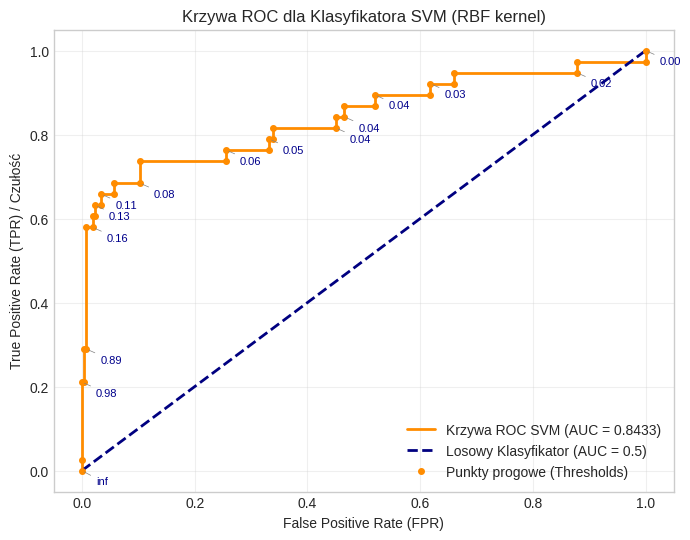


Wynik AUC dla SVM: 0.8433
Model jest lepszy niż losowe zgadywanie.


In [10]:
# Import niezbędnych bibliotek
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  # Zmiana: Import Support Vector Classifier
from sklearn.metrics import roc_curve, auc

# Ustawienia wykresu dla lepszej widoczności w Colab
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# --- 1. Generowanie danych (syntetyczny problem klasyfikacji binarnej) ---
X, y = make_classification(n_samples=1000,
                           n_features=10,
                           n_informative=2,
                           n_redundant=0,
                           n_classes=2,
                           n_clusters_per_class=1,
                           weights=[0.9, 0.1],  # 90% klasa 0, 10% klasa 1 (niezbalansowane)
                           flip_y=.05,
                           random_state=42)

# Podział danych na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 2. Trenowanie modelu SVM ---
# Zmiana: Inicjalizacja SVM.
# UWAGA: probability=True jest konieczne, aby użyć metody predict_proba()!
# SVM domyślnie używa 'decision_function' (odległość od granicy), a nie prawdopodobieństw.
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# --- 3. Generowanie PRAWDOPODOBIEŃSTW dla krzywej ROC ---
# Pobieramy prawdopodobieństwa przynależności do klasy pozytywnej (klasa 1)
y_scores = svm_model.predict_proba(X_test)[:, 1]

# --- 4. Obliczanie Krzywej ROC i AUC ---
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# --- 5. Wizualizacja Krzywej ROC ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Krzywa ROC SVM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Losowy Klasyfikator (AUC = 0.5)')

# Rysowanie punktów na krzywej
plt.plot(fpr, tpr, 'o', color='darkorange', markersize=4,
         label='Punkty progowe (Thresholds)')

# Dodawanie etykiet progów (filtrowanie, aby uniknąć bałaganu na wykresie)
# Wyświetlamy co n-ty próg lub te, które są wystarczająco oddalone,
# tutaj prosty filtr by nie wyświetlać setek etykiet.
indices_to_plot = np.linspace(0, len(thresholds)-1, 15, dtype=int)

for i in indices_to_plot:
    # Pomijamy skrajne wartości dla czytelności, jeśli trzeba
    if i < len(thresholds):
        plt.annotate(f'{thresholds[i]:.2f}',
                     (fpr[i], tpr[i]),
                     textcoords="offset points",
                     xytext=(10, -10),
                     ha='left',
                     fontsize=8,
                     color='darkblue',
                     arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Czułość')
plt.title('Krzywa ROC dla Klasyfikatora SVM (RBF kernel)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# --- 6. Wyjaśnienie wyniku ---
print(f"\nWynik AUC dla SVM: {roc_auc:.4f}")
if roc_auc > 0.5:
    print("Model jest lepszy niż losowe zgadywanie.")
else:
    print("Model jest gorszy lub równy losowemu zgadywaniu.")

SVM zwraca wyniki ciągłe, dlatego przy zmianie progu punkty są klasyfikowane jeden po drugim, co tworzy kształt schodków. Natomiast K-NN produkuje wyniki dyskretne, co powoduje, że wiele punktów ma identyczny wynik. Zmiana progu w K-NN sprawia, że cała grupa punktów zmienia klasę jednocześnie, dlatego punkty na wykresie połączone są ukośnymi liniami.